### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs
#### Parte 3 - Previsão do valor total

**Objetivo geral - Previsão do valor total da internação**

Desenvolver modelos de regressão para estimar o valor total da internação a partir de variáveis clínicas, demográficas, administrativas e de permanência hospitalar da base SIH/SUS tratada.

---

## Sumário da Parte 3

**Item 1 - Modelo base para previsão do valor total**

- **1.1 - Carregamento e amostra inicial**
- **1.2 - Descrição estatística inicial**
- **1.3 - Dimensões da base tratada**
- **1.4 - Seleção inicial das features e matriz de correlação**
- **1.5 - Separação entre treino e teste**
- **1.6 - Treinamento do modelo base**
- **1.7 - Avaliação do modelo base**
- **1.8 - Teste com PCA**

**Conclusão da Fase 1 - Avaliação do modelo base**

- **Resumo das métricas obtidas no modelo base**
- **Observação sobre PCA e impacto dos outliers**
- **Encaminhamento para melhoria do modelo**

**Item 2 - Aplicação de transformação logarítmica na variável-alvo**

- **2.1 - Verificação de outliers na variável-alvo**
- **2.2 - Verificação dos mínimos e máximos por faixa**
- **2.3 - Aplicação de cap nos valores extremos**
- **2.4 - Separação das bases**
- **2.5 - Aplicação de cap na base de treino**
- **2.6 - Treinamento do modelo**
- **2.7 - Conversão da previsão para a escala original**
- **2.8 - Avaliação dos resultados com reversão logarítmica**
- **2.9 - Avaliação dos resultados na escala logarítmica**
- **2.10 - Conclusão sobre a transformação logarítmica**

**Item 3 - Melhorando o modelo com engenharia de features**

- **3.1 - Criar faixas de idade**
- **3.2 - Criar faixas de dias totais**
- **3.3 - Criar categorias de procedimentos realizados**
- **3.4 - Preparar complexidade do atendimento para label encoding**
- **3.5 - Separar as bases de treino e teste**
- **3.6 - Aplicar target encoding para os grupos de CID principal**
- **3.7 - Reavaliar as correlações entre as colunas novas**
- **3.8 - Treinar o modelo melhorado**
- **3.9 - Avaliação do modelo melhorado**
- **3.10 - Teste com PCA no modelo melhorado**

**Relatório de Avaliação e Performance do Modelo**

- **Comparativo de resultados**
- **Conclusão**
- **Considerações finais e perspectivas**

#### Item 1 - Modelo base para previsão do valor total

**Neste passo vamos:**

- **1.1 - Carregar e visualizar uma amostra da base tratada** para confirmar que o arquivo `2025_tratado.parquet` foi lido corretamente.
- **1.2 - Avaliar a descrição estatística geral** para observar as variáveis numéricas que serão usadas no modelo base.
- **1.3 - Conferir as dimensões da base** para registrar o volume disponível para treinamento.
- **1.4 - Selecionar features iniciais e calcular a matriz de correlação** para entender a relação linear com `VAL_TOT`.
- **1.5 - Separar treino e teste** antes de treinar o modelo.
- **1.6 - Treinar uma regressão linear base** para estabelecer uma referência inicial.
- **1.7 - Avaliar o modelo base** com R², MAE, RMSE e MAPE.
- **1.8 - Aplicar PCA como experimento comparativo** e comparar o resultado com o modelo base.


##### 1.1 - Carregamento e amostra inicial

Leitura da base tratada gerada na parte 2 e visualização dos primeiros registros.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

dados_fase_1 = pd.read_parquet('2025_tratado.parquet')
dados_fase_1 = dados_fase_1[dados_fase_1["VAL_TOT"]>0]
dados_fase_1.head()

,MES_CMPT,IDENT,MUNIC_RES,NASC,SEXO,COD_IDADE,IDADE,NUM_FILHOS,INSTRU,GESTRISCO,CONTRACEP1,CONTRACEP2,RACA_COR,DT_INTER,DT_SAIDA,DIAS_PERM,QT_DIARIAS,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,MORTE,PROC_REA,DIAG_PRINC,DIAG_SECUN,CID_NOTIF,CID_ASSO,CID_MORTE,DIAGSEC1,DIAGSEC2,DIAGSEC3,DIAGSEC4,DIAGSEC5,DIAGSEC6,DIAGSEC7,DIAGSEC8,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,COMPLEX,VAL_TOT,DIAR_ACOM,NASC_DT,ANO_NASC,IDADE_ANOS,DIAG_SECUN_VALIDA,DIAG_PRINC_INT,DIAG_SECUN_INT,CID_ASSO_INT,CID_NOTIF_INT,DIAGSEC1_INT,DIAGSEC2_INT,DIAGSEC3_INT,DIAGSEC4_INT,DIAGSEC5_INT,DIAGSEC6_INT,DIAGSEC7_INT,DIAGSEC8_INT,DIAGSEC9_INT,CID_MORTE_INT,DIAG_PRINC_GRUPO,VIOLENCIA_MULHER_NIVEL,CANCER_MAMA_NIVEL
9,01,1,330350,19990109,3,4,26,0,0,1,00,00,03,20250114,20250124,10,10,0,0,0,0,0,0,0,0,0,0304100021,C811,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,367.44,0,1999-01-09,1999,26,False,3811,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0
10,01,1,330320,19870221,1,4,37,0,0,1,00,00,03,20250121,20250124,3,3,0,0,0,0,0,0,0,0,0,0304080020,C811,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,03,1116.00,2,1987-02-21,1987,37,False,3811,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0
11,01,1,330455,20000512,1,4,24,0,0,1,00,00,03,20250116,20250127,11,11,0,0,0,0,0,0,0,0,0,0303020040,D570,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,911.44,8,2000-05-12,2000,24,False,4570,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0
12,01,1,330510,19760905,3,4,48,0,0,1,00,00,02,20250120,20250127,7,7,0,0,0,0,0,0,0,0,0,0303020040,D570,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,801.93,0,1976-09-05,1976,48,False,4570,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0
13,01,1,330455,19640319,1,4,60,0,0,1,00,00,03,20250121,20250128,7,7,0,0,0,0,0,0,0,0,0,0304080020,C925,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,03,2472.66,5,1964-03-19,1964,60,False,3925,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0


##### 1.2 - Descrição estatística inicial

Resumo estatístico das colunas numéricas para observar escala, dispersão e possíveis valores extremos.

In [2]:
dados_fase_1.describe()

,IDADE,NUM_FILHOS,DIAS_PERM,QT_DIARIAS,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,MORTE,VAL_TOT,DIAR_ACOM,NASC_DT,ANO_NASC,IDADE_ANOS,DIAG_PRINC_INT,DIAG_SECUN_INT,CID_ASSO_INT,CID_NOTIF_INT,DIAGSEC1_INT,DIAGSEC2_INT,DIAGSEC3_INT,DIAGSEC4_INT,DIAGSEC5_INT,DIAGSEC6_INT,DIAGSEC7_INT,DIAGSEC8_INT,DIAGSEC9_INT,CID_MORTE_INT,DIAG_PRINC_GRUPO,VIOLENCIA_MULHER_NIVEL,CANCER_MAMA_NIVEL
count,854091.000000,854091.000000,854091.000000,854091.000000,854091.0,854091.0,854091.0,854091.000000,854091.0,854091.0,854091.0,854091.000000,854091.000000,854091.000000,854091.000000,854091,854091.000000,854091.000000,854091.000000,854091.0,854091.0,854091.000000,854091.000000,854091.000000,854091.000000,854091.000000,854091.000000,854091.000000,854091.000000,854091.000000,854091.000000,854091.0,854091.000000,854091.000000,854091.000000
mean,44.420523,0.098772,5.518549,4.926573,0.0,0.0,0.0,0.695550,0.0,0.0,0.0,0.047582,0.062711,1798.655162,2.174284,1980-09-08 12:15:56.014288,1980.201023,44.286142,11296.827376,0.0,0.0,1108.737904,3799.118775,321.424618,155.318933,76.491562,34.707443,15.448568,5.759649,1.541318,0.065333,0.0,8.963910,0.117792,0.029838
min,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,23.450000,0.000000,1897-01-22 00:00:00,1897.000000,0.000000,100.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,25.000000,0.000000,1.000000,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,393.260000,0.000000,1959-07-07 00:00:00,1959.000000,25.000000,5145.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,7.000000,0.000000,0.000000
50%,44.000000,0.000000,3.000000,2.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,699.460000,0.000000,1980-07-23 00:00:00,1980.000000,44.000000,11509.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,9.000000,0.000000,0.000000
75%,65.000000,0.000000,6.000000,6.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,1322.330000,2.000000,2000-01-19 00:00:00,2000.000000,65.000000,15800.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,12.000000,0.000000,0.000000
max,99.000000,69.000000,345.000000,345.000000,0.0,0.0,0.0,184.000000,0.0,0.0,0.0,96.000000,1.000000,163570.270000,204.000000,2025-12-31 00:00:00,2025.000000,100.000000,26998.000000,0.0,0.0,26302.000000,26999.000000,26992.000000,26993.000000,26993.000000,26993.000000,26993.000000,26998.000000,26998.000000,2600.000000,0.0,16.000000,3.000000,3.000000
std,24.552384,0.550825,8.164142,7.170479,0.0,0.0,0.0,3.506326,0.0,0.0,0.0,0.896687,0.242443,4175.469668,4.858201,NaN,24.904524,24.860561,6798.857920,0.0,0.0,5280.377492,8341.001515,2249.162701,1597.489850,1152.556726,797.068297,533.742529,318.722395,167.875655,10.797577,0.0,4.541173,0.350382,0.293361


##### 1.3 - Dimensões da base tratada

Conferência da quantidade de linhas e colunas disponíveis para a modelagem.

In [3]:
dados_fase_1.shape

(854091, 74)

##### 1.4 - Seleção inicial das features e matriz de correlação

Seleção de variáveis candidatas para o modelo base e análise de correlação com `VAL_TOT`.

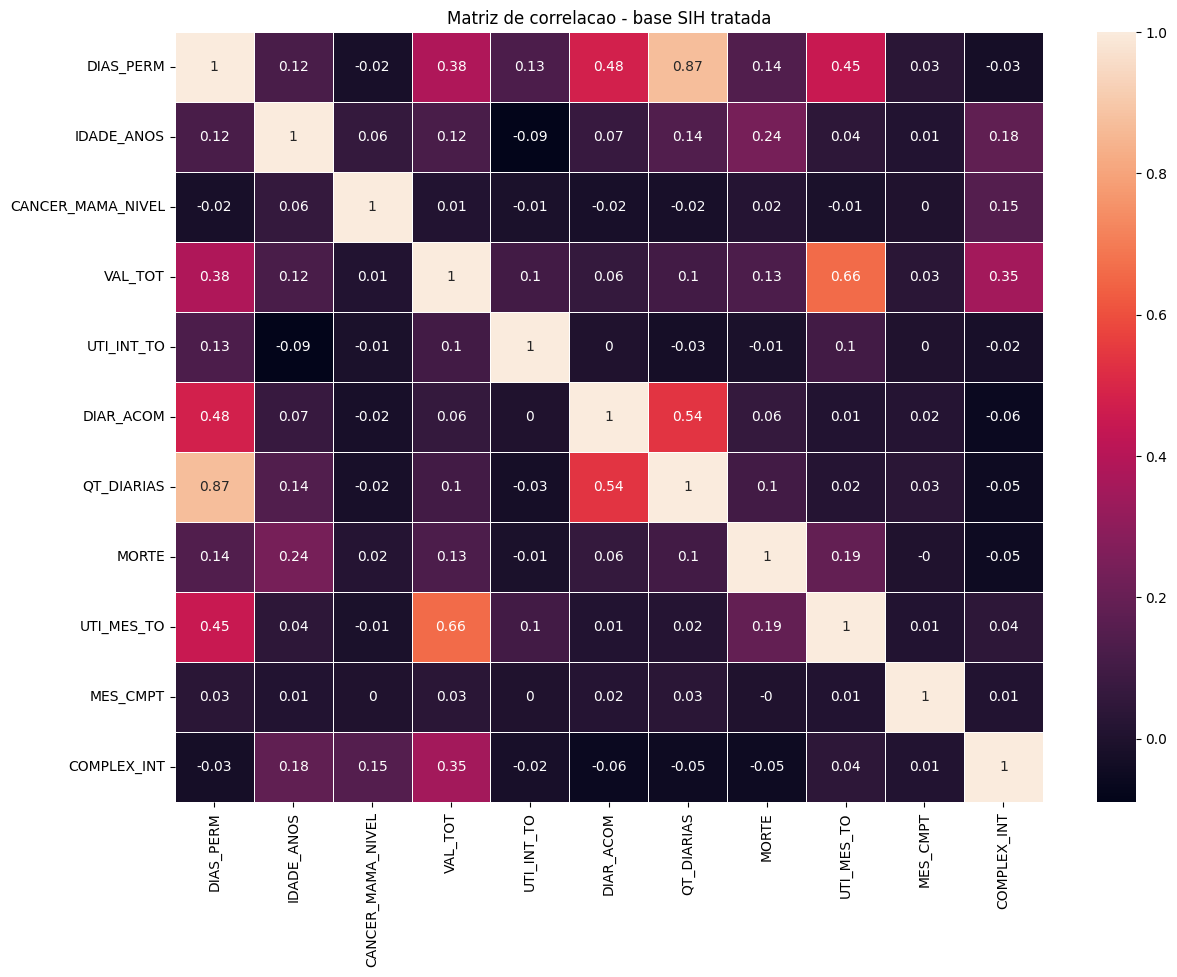

In [4]:
dadosCalcValorTotal = dados_fase_1[[
    "DIAS_PERM",
    "IDADE_ANOS",
    "CANCER_MAMA_NIVEL",
    "VAL_TOT",
    "UTI_INT_TO",
    "DIAR_ACOM",
    "QT_DIARIAS",
    "MORTE",
    "COMPLEX",
    "PROC_REA",
    "UTI_MES_TO",
    "MES_CMPT"
]]
    
dadosCalcValorTotal["COMPLEX_INT"] = dados_fase_1["COMPLEX"].astype(int)
dadosCalcValorTotal["MES_CMPT"] = dados_fase_1["MES_CMPT"].astype(int)
correlation_matrix = dadosCalcValorTotal.corr(numeric_only=True).round(2)
fig, ax = plt.subplots(figsize=(14, 10))
sb.heatmap(correlation_matrix, annot=True, linewidths=.5, ax=ax)
plt.title('Matriz de correlacao - base SIH tratada')
plt.show()

In [5]:
pd.set_option("display.max_rows", None)
correlation_matrix["VAL_TOT"].sort_values(ascending=False)

VAL_TOT              1.00
UTI_MES_TO           0.66
DIAS_PERM            0.38
COMPLEX_INT          0.35
MORTE                0.13
IDADE_ANOS           0.12
UTI_INT_TO           0.10
QT_DIARIAS           0.10
DIAR_ACOM            0.06
MES_CMPT             0.03
CANCER_MAMA_NIVEL    0.01
Name: VAL_TOT, dtype: float64

**Nossas features possuem baixa correlação, por isso a princípio não vamos aplicar PCA como etapa principal do modelo base.**

##### 1.5 - Separação entre treino e teste

Separação da base para avaliar o modelo em dados não vistos durante o treinamento.

In [6]:
from sklearn.model_selection import train_test_split

X_fase_1 = dadosCalcValorTotal[["UTI_MES_TO", "DIAS_PERM","QT_DIARIAS","DIAR_ACOM","IDADE_ANOS","COMPLEX_INT","MES_CMPT"]]
y_fase_1 = dadosCalcValorTotal["VAL_TOT"]

X_train_fase_1, X_test_fase_1, y_train_fase_1, y_test_fase_1 = train_test_split(
    X_fase_1, y_fase_1, test_size=0.2, random_state=7
)

print(len(X_train_fase_1), "treinamento +", len(X_test_fase_1), "teste")

683272 treinamento + 170819 teste


##### 1.6 - Treinamento do modelo base

Treinamento de uma regressão linear para estabelecer o desempenho inicial.

In [7]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression().fit(X_train_fase_1, y_train_fase_1)

y_pred_fase_1 = modelo.predict(X_test_fase_1)

##### 1.7 - Avaliação do modelo base

Cálculo das métricas de regressão para avaliar erro absoluto, erro quadrático e proporção da variância explicada.

In [8]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

epsilon = 1e-8

print("R2:", r2_score(y_test_fase_1, y_pred_fase_1))
print("MAE:", mean_absolute_error(y_test_fase_1, y_pred_fase_1))
print("RMSE:", np.sqrt(mean_squared_error(y_test_fase_1, y_pred_fase_1)))
print("MAPE:", np.mean(np.abs((y_test_fase_1 - y_pred_fase_1) / (y_test_fase_1 + epsilon))) * 100)

R2: 0.5664386692065172
MAE: 927.2977415269881
RMSE: 2725.7324866556505
MAPE: 128.8541879722896


##### 1.8 - Teste com PCA

Aplicação de PCA como experimento para verificar se a redução de dimensionalidade melhora o desempenho do modelo.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

melhor_n = None
melhor_r2 = -np.inf
melhor_mae = None
melhor_rmse = None
melhor_mape = None

for n in range(1, X_test_fase_1.shape[1] + 1):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n)),
        ("reg", LinearRegression())
    ])

    pipeline.fit(X_train_fase_1, y_train_fase_1)

    y_pred = pipeline.predict(X_test_fase_1)

    r2 = r2_score(y_test_fase_1, y_pred)
    mae = mean_absolute_error(y_test_fase_1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fase_1, y_pred))
    mape = np.mean(np.abs((y_test_fase_1 - y_pred) / (y_test_fase_1 + 1e-8))) * 100

    if r2 > melhor_r2:
        melhor_n = n
        melhor_r2 = r2
        melhor_mae = mae
        melhor_rmse = rmse
        melhor_mape = mape

print("Melhor número de colunas do PCA:", melhor_n)
print("R2:", melhor_r2)
print("MAE:", melhor_mae)
print("RMSE:", melhor_rmse)
print("MAPE:", melhor_mape)

Melhor número de colunas do PCA: 7
R2: 0.5664386692065171
MAE: 927.2977415269715
RMSE: 2725.732486655651
MAPE: 128.85418797236605


#### Conclusão da Fase 1 - Avaliação do modelo base

##### Resumo da avaliação

O modelo apresenta um **R² de 0,5664**, indicando que aproximadamente **56,6% da variabilidade dos custos hospitalares** é explicada pelas variáveis selecionadas.

##### Métricas de erro

| Métrica | Resultado | Interpretação |
|---|---:|---|
| R² - Coeficiente de determinação | 0,5664 | O modelo explica cerca de 56,6% da variação observada em `VAL_TOT`. |
| MAE - Erro Médio Absoluto | R$ 927,30 | Em média, as previsões desviam R$ 927,30 do valor faturado. |
| RMSE - Raiz do Erro Quadrático Médio | R$ 2.725,73 | Penaliza mais os erros de grande magnitude. Como está cerca de 2,9 vezes acima do MAE, indica presença de outliers relevantes. |
| MAPE - Erro Percentual Absoluto Médio | 128,85% | O erro percentual é elevado, especialmente por causa de registros com valores faturados baixos. |

##### Observação sobre PCA

Os resultados obtidos com e sem PCA ficaram praticamente idênticos. Isso indica que a variância dos dados já está bem representada pelas variáveis originais.

A redução de dimensionalidade não removeu ruídos significativos, mas também não prejudicou o poder preditivo do modelo.

##### Conclusão

A qualidade do resultado é **moderada**. Embora o modelo capture parte da tendência geral, o alto valor do RMSE e a proximidade dos resultados com e sem PCA reforçam a necessidade de tratar a assimetria da base.

Uma alternativa para as próximas melhorias é aplicar transformação logarítmica em `VAL_TOT`, reduzindo o impacto dos valores extremos no faturamento.

#### Item 2 - Aplicação de transformação logarítmica na variável-alvo

* Vamos utilizar as bases da fase 1 para tentar melhorar o modelo apresentado anteriormente.


##### 2.1 - Verificação de outliers na variável-alvo


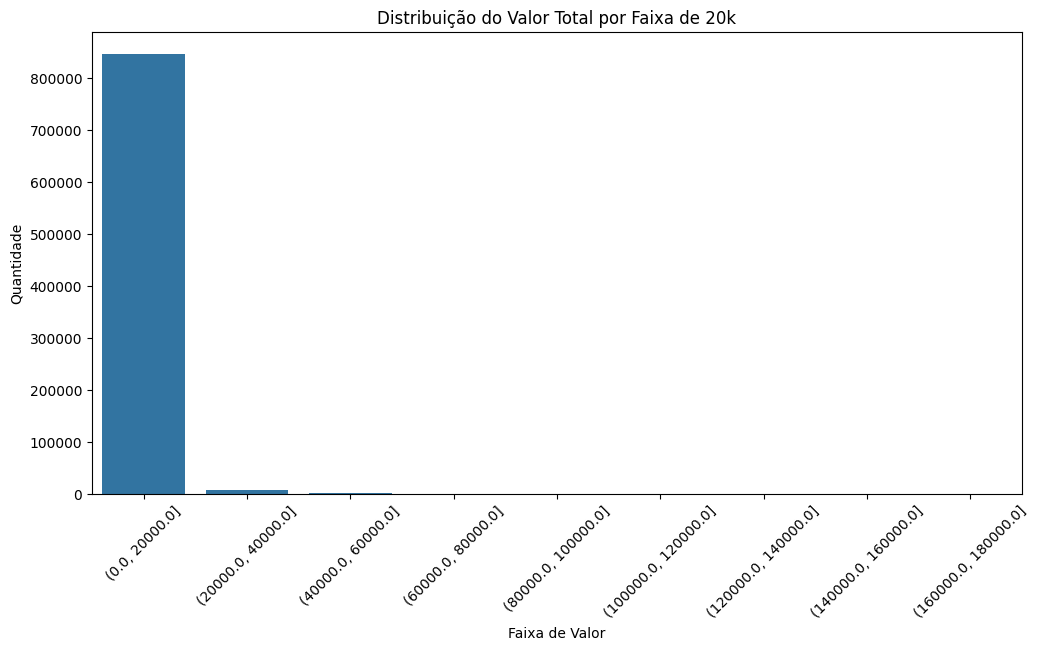

In [10]:
import numpy as np

max_val = dados_fase_1["VAL_TOT"].max()

bins = np.arange(0, max_val + 20000, 20000)

dados_fase_1["faixa_valor"] = pd.cut(
    dados_fase_1["VAL_TOT"],
    bins=bins
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.countplot(
    data = dados_fase_1,
    x = "faixa_valor"
)

plt.xticks(rotation=45)
plt.title("Distribuição do Valor Total por Faixa de 20k")
plt.xlabel("Faixa de Valor")
plt.ylabel("Quantidade")

plt.show()

In [11]:
bins = [0, 2000, 20000, 40000, np.inf]
labels = ["0-2k", "2k-20k", "20k-40k", "40k+"]

dados_fase_1["faixa_outliers"] = pd.cut(
    dados_fase_1["VAL_TOT"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

faixas_interesse = ["0-2k", "20k-40k", "40k+"]

dados_outliers = dados_fase_1[
    dados_fase_1["faixa_outliers"].isin(faixas_interesse)
]

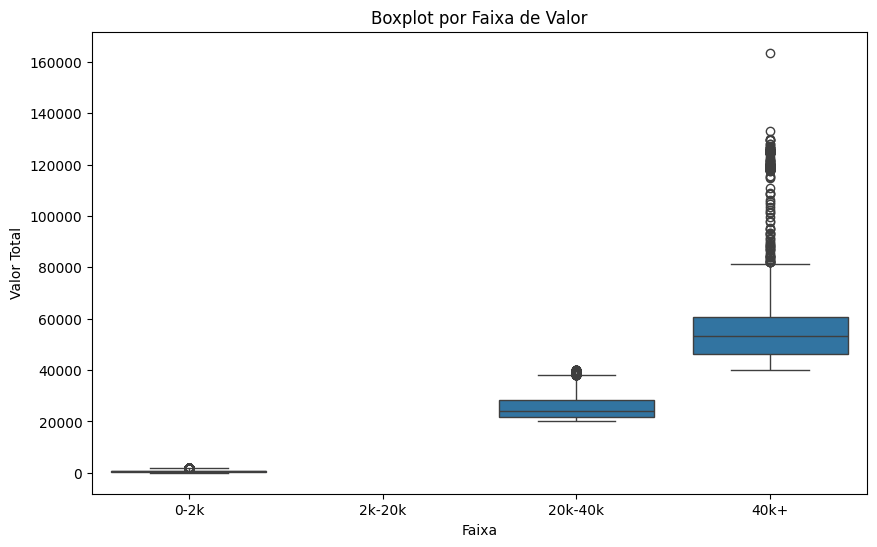

In [12]:
import seaborn as sb
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sb.boxplot(
    data=dados_outliers,
    x="faixa_outliers",
    y="VAL_TOT"
)

plt.title("Boxplot por Faixa de Valor")
plt.xlabel("Faixa")
plt.ylabel("Valor Total")

plt.show()

##### 2.2 - Verificação dos mínimos e máximos por faixa


In [13]:
dados_fase_1.groupby("faixa_outliers")["VAL_TOT"].describe()

,count,mean,std,min,25%,50%,75%,max
faixa_outliers,,,,,,,,
0-2k,699316.0,660.233530,421.583101,23.45,328.34,601.120,873.9100,1999.97
2k-20k,146545.0,5551.674258,3762.599264,2000.09,2723.79,4241.700,7119.8200,19999.39
20k-40k,6764.0,25516.189215,4838.984768,20000.16,21754.91,23962.735,28212.5125,39990.42
40k+,1466.0,60260.372394,22589.987447,40003.62,46420.03,53451.630,60475.3325,163570.27


<Axes: ylabel='VAL_TOT'>

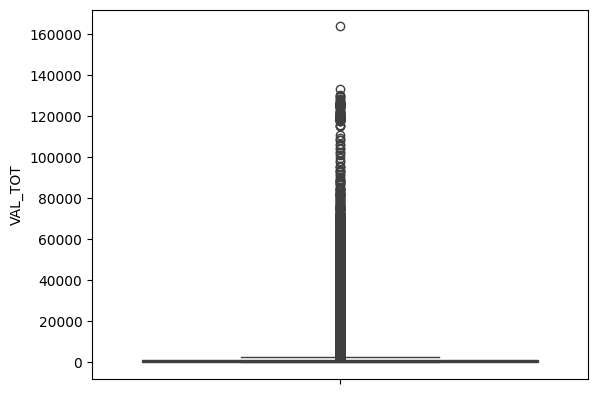

In [14]:
sb.boxplot(dados_fase_1["VAL_TOT"])

<Axes: ylabel='VAL_TOT_log'>

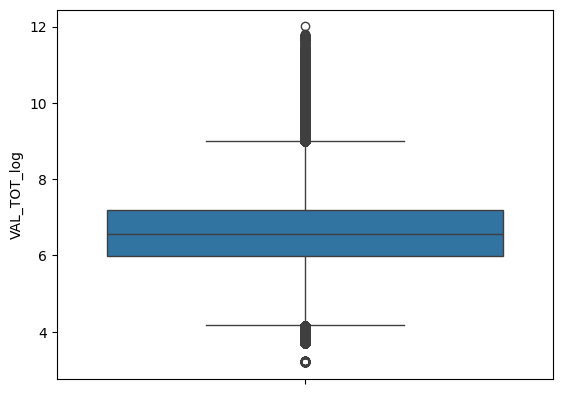

In [15]:
dados_fase_1["VAL_TOT_log"] = np.log1p(dados_fase_1["VAL_TOT"])
sb.boxplot(dados_fase_1["VAL_TOT_log"])

##### 2.3 - Aplicação de cap nos valores extremos

- Valores maiores que o percentil 99% são reduzidos para o limite.
- Valores abaixo desse limite permanecem iguais.


In [16]:
upper = dados_fase_1["VAL_TOT_log"].quantile(0.99)
dados_fase_1["VAL_TOT_log"] = dados_fase_1["VAL_TOT_log"].clip(upper=upper)

<Axes: ylabel='VAL_TOT_log'>

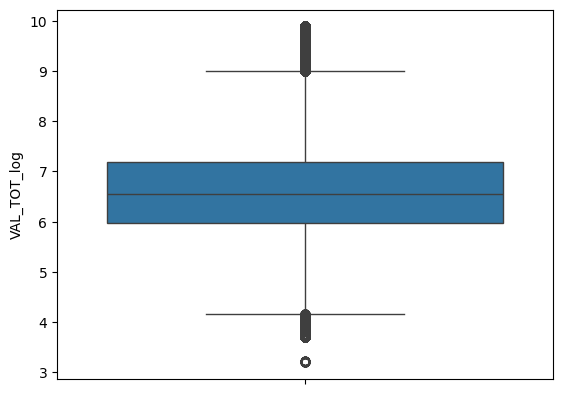

In [17]:
sb.boxplot(dados_fase_1["VAL_TOT_log"])

##### 2.4 - Separação das bases


In [18]:
X_fase_2 = dadosCalcValorTotal[["UTI_MES_TO", "DIAS_PERM","QT_DIARIAS","DIAR_ACOM","IDADE_ANOS","COMPLEX_INT","MES_CMPT"]]
y_fase_2 = np.log1p(dadosCalcValorTotal["VAL_TOT"])

X_train_fase_2, X_test_fase_2, y_train_fase_2, y_test_fase_2 = train_test_split(
    X_fase_2, y_fase_2, test_size=0.2, random_state=7
)

print(len(X_train_fase_2), "treinamento +", len(X_test_fase_2), "teste")


683272 treinamento + 170819 teste


##### 2.5 - Aplicação de cap na base de treino


In [19]:
upper = y_train_fase_2.quantile(0.99)

y_train_fase_2 = y_train_fase_2.clip(upper=upper)

##### 2.6 - Treinamento do modelo


In [20]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression().fit(X_train_fase_2, y_train_fase_2)

y_pred_fase_2 = modelo.predict(X_test_fase_2)

##### 2.7 - Conversão da previsão para a escala original


In [21]:
y_pred_real = np.expm1(y_pred_fase_2)
y_test_real = np.expm1(y_test_fase_2)

##### 2.8 - Avaliação dos resultados com reversão logarítmica


In [22]:
epsilon = 1e-8

print("R2:", r2_score(y_test_real, y_pred_real))
print("MAE:", mean_absolute_error(y_test_real, y_pred_real))
print("RMSE:", np.sqrt(mean_squared_error(y_test_real, y_pred_real)))
print("MAPE:", np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + epsilon))) * 100)

R2: -21276641481.406563
MAE: 2532982.1688702386
RMSE: 603822786.2829341
MAPE: 2903.1887432642266


##### 2.9 - Avaliação dos resultados na escala logarítmica


In [23]:
epsilon = 1e-8

print("R2:", r2_score(y_test_fase_2, y_pred_fase_2))
print("MAE:", mean_absolute_error(y_test_fase_2, y_pred_fase_2))
print("RMSE:", np.sqrt(mean_squared_error(y_test_fase_2, y_pred_fase_2)))
print("MAPE:", np.mean(np.abs((y_test_fase_2 - y_pred_fase_2) / (y_test_fase_2 + epsilon))) * 100)

R2: 0.4053407494948339
MAE: 0.683944441353093
RMSE: 0.8981138524325504
MAPE: 10.932920688079067


##### 2.10 - Conclusão sobre a transformação logarítmica

Embora a literatura recomende o uso de transformações logarítmicas para mitigar a assimetria em dados financeiros e de saúde, os experimentos demonstraram que a aplicação de `ln(y)` introduziu instabilidade numérica significativa durante a fase de anti-logaritmo, isto é, na reversão para a escala original.

Na escala logarítmica, o modelo apresentou **R² de 0,4053**, **MAE de 0,6839**, **RMSE de 0,8981** e **MAPE de 10,93%**. Porém, após a reversão para reais, os resultados ficaram inadequados: **R² de -21.276.641.481,4066**, **MAE de R$ 2.532.982,17**, **RMSE de R$ 603.822.786,28** e **MAPE de 2903,19%**.

O modelo treinado com os dados em sua escala original apresentou maior robustez e métricas de erro mais consistentes. Isso sugere que, para este conjunto de dados do DATASUS, a relação entre as variáveis preditoras e o custo total é mais bem capturada em um espaço linear simples, no qual erros de predição não são amplificados exponencialmente.

#### Item 3 - Melhorando o modelo com engenharia de features

**Neste passo vamos:**

- **3.1 - Criar faixas de idade e aplicar label encoding** para capturar diferenças de custo por ciclo de vida.
- **3.2 - Criar faixas de dias totais e aplicar label encoding** para representar permanências curtas, médias e longas.
- **3.3 - Criar categorias de procedimentos realizados e aplicar one-hot encoding** usando o grupo inicial do código do procedimento.
- **3.4 - Aplicar label encoding em complexidade** para tratar `COMPLEX` como variável categórica ordinal simples no experimento.
- **3.5 - Separar as bases de treino e teste** antes de aplicar os encodings.
- **3.6 - Aplicar target encoding para CID principal** usando somente a base de treino, evitando vazamento de informação.
- **3.7 - Reavaliar as correlações entre as colunas novas**.
- **3.8 - Treinar o modelo melhorado** com as features criadas.
- **3.9 - Avaliar o modelo melhorado** com as mesmas métricas usadas no modelo base.
- **3.10 - Testar PCA no modelo melhorado**.

Como `PROC_REA` é um código de procedimento e não uma escala numérica contínua, a faixa do procedimento será representada pelos dois primeiros dígitos do código. Para `DIAG_PRINC`, usaremos target encoding porque a cardinalidade pode ser maior e o one-hot encoding poderia aumentar muito a matriz de treino.

- Resumo sobre **one-hot encoding** e **label encoding**:
    1. As colunas categóricas criadas nos itens 3.1, 3.2 e 3.4 serão transformadas com label encoding.
        - Elas possuem ordenação ou gradação simples no experimento, como faixas de idade, faixas de dias de internação e nível de complexidade.
    2. A coluna que representa o procedimento realizado não possui ordenação natural. Por isso, neste caso, vamos aplicar one-hot encoding.

**Estes passos podem ser aplicados por pipeline, mas, para fins didáticos, faremos cada etapa separadamente.**

In [24]:
dados_base_fase_3 = pd.read_parquet('2025_tratado.parquet')
dados_base_fase_3 = dados_base_fase_3[dados_base_fase_3["VAL_TOT"]>0]
dados_fase_3 = pd.DataFrame()
dados_fase_3["VAL_TOT"] = dados_base_fase_3["VAL_TOT"]
dados_fase_3["DIAG_PRINC"] = dados_base_fase_3["DIAG_PRINC"]
dados_fase_3["UTI_MES_TO"] = dados_base_fase_3["UTI_MES_TO"]
dados_fase_3["QT_DIARIAS"] = dados_base_fase_3["QT_DIARIAS"]
dados_fase_3["DIAR_ACOM"] = dados_base_fase_3["DIAR_ACOM"]
dados_fase_3["COMPLEX"] = dados_base_fase_3["COMPLEX"]
dados_fase_3["PROC_REA"] = dados_base_fase_3["PROC_REA"]
dados_fase_3["DIAS_PERM"] = dados_base_fase_3["DIAS_PERM"]
dados_fase_3["IDADE_ANOS"] = dados_base_fase_3["IDADE_ANOS"]



##### 3.1 - Criar faixas de idade

- Criar categorias de idade para substituir uma relação puramente linear por grupos mais interpretáveis.
- Aplicar label encoding.


In [25]:
bins = [0, 1, 5, 12, 18, 40, 60, 80, 120]
mapa = {
    "0-1 (lactente)": 1,
    "1-4 (infantil)": 2,
    "5-11 (criança)": 3,
    "12-17 (adolescente)": 4,
    "18-39 (adulto jovem)": 5,
    "40-59 (adulto)": 6,
    "60-79 (idoso)": 7,
    "80+ (longevo)": 8
}

def faixa_idade_label_enc(df):
    df["fx_idade"] = pd.cut(
        df["IDADE_ANOS"],
        bins=bins,
        labels=mapa.keys(),
        include_lowest=True
    )

    df["fx_idade_enc"] = df["fx_idade"].map(mapa)
    df["fx_idade_enc"] = df["fx_idade_enc"].astype(int)
    return df.drop(columns=["IDADE_ANOS", "fx_idade"])   

##### 3.2 - Criar faixas de dias totais

- Criar categorias para permanência hospitalar, separando internações curtas, médias, longas e muito longas.
- Aplicar label encoding.


In [26]:
bins = [0, 1, 3, 7, 15, 30, np.inf]
mapa = {
    "0-1 (curtíssima)": 1,
    "2-3 (curta)": 2,
    "4-7 (moderada)": 3,
    "8-15 (prolongada)": 4,
    "16-30 (longa)": 5,
    "30+ (muito longa)": 6
}

def faixa_dias_inter_label_enc(df):
    df["fx_dias_inter"] = pd.cut(
        df["DIAS_PERM"],
        bins=bins,
        labels=mapa.keys(),
        include_lowest=True
    )
    df["fx_dias_inter_enc"] = df["fx_dias_inter"].map(mapa)
    df["fx_dias_inter_enc"] = df["fx_dias_inter_enc"].astype(int)
    return df.drop(columns=["DIAS_PERM", "fx_dias_inter"])   


##### 3.3 - Criar categorias de procedimentos realizados

Agrupamento de `PROC_REA` pelos dois primeiros dígitos do código, reduzindo cardinalidade antes do one-hot encoding.


In [27]:
dados_fase_3.info()

<class 'pandas.DataFrame'>
Index: 854091 entries, 9 to 925239
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   VAL_TOT     854091 non-null  float64
 1   DIAG_PRINC  854091 non-null  str    
 2   UTI_MES_TO  854091 non-null  int64  
 3   QT_DIARIAS  854091 non-null  int64  
 4   DIAR_ACOM   854091 non-null  int64  
 5   COMPLEX     854091 non-null  str    
 6   PROC_REA    854091 non-null  str    
 7   DIAS_PERM   854091 non-null  int64  
 8   IDADE_ANOS  854091 non-null  int64  
dtypes: float64(1), int64(5), str(3)
memory usage: 78.4 MB


In [28]:
mapa_proc = {
    "01": "Promoção/Prevenção",
    "02": "Diagnóstico",
    "03": "Clínico",
    "04": "Cirúrgico",
    "05": "Transplantes",
    "06": "Medicamentos",
    "07": "Órteses/Próteses",
    "08": "Ações complementares"
}

def categoria_one_hot_enc(df):
    df["categ_proced"] = df["PROC_REA"].str[:2].map(mapa_proc)
    dummies = pd.get_dummies(df["categ_proced"], prefix="categ_proced")
    df = pd.concat([df, dummies], axis=1)
    return df.drop(columns=["PROC_REA", "categ_proced"])


##### 3.4 - Preparar complexidade do atendimento para label encoding

Padronização de `COMPLEX` como variável categórica.

1. Baixa
2. Média
3. Alta


In [29]:
def complexidade_label_enc(df):
    df["complex_nivel"] = df["COMPLEX"].astype(int)   
    return df.drop(columns=["COMPLEX"])

##### 3.5 - Separar as bases de treino e teste

Para evitar riscos de overfitting, vamos realizar as aplicações de one-hot encoding e target encoding após a separação das bases de treino e teste.


In [30]:
X_train_fase_3, X_test_fase_3, y_train_fase_3, y_test_fase_3 = train_test_split(
    dados_fase_3.drop(columns=["VAL_TOT"]), dados_fase_3["VAL_TOT"], test_size=0.2, random_state=7
)

X_train_fase_3 = faixa_dias_inter_label_enc(X_train_fase_3)
X_test_fase_3 = faixa_dias_inter_label_enc(X_test_fase_3)

X_train_fase_3 = faixa_idade_label_enc(X_train_fase_3)
X_test_fase_3 = faixa_idade_label_enc(X_test_fase_3)

X_train_fase_3 = categoria_one_hot_enc(X_train_fase_3)
X_test_fase_3 = categoria_one_hot_enc(X_test_fase_3)

X_train_fase_3 = complexidade_label_enc(X_train_fase_3)
X_test_fase_3 = complexidade_label_enc(X_test_fase_3)


##### 3.6 - Aplicar target encoding para os grupos de CID principal

O target encoding transforma cada grupo de CID principal na média suavizada de `VAL_TOT`.
A principal motivação é que há um número significativo de classes para o CID principal. Portanto, não podemos aplicar técnicas como label encoding ou one-hot encoding sem aumentar excessivamente a dimensionalidade. Neste caso, vamos obter a média de gastos de cada CID para tratar o modelo.

* Para evitar overfitting:
 - Vamos obter as médias pela base de treino.
 - Vamos aplicar essas médias em todo o modelo.


In [31]:
dados_fase_3.info()

<class 'pandas.DataFrame'>
Index: 854091 entries, 9 to 925239
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   VAL_TOT     854091 non-null  float64
 1   DIAG_PRINC  854091 non-null  str    
 2   UTI_MES_TO  854091 non-null  int64  
 3   QT_DIARIAS  854091 non-null  int64  
 4   DIAR_ACOM   854091 non-null  int64  
 5   COMPLEX     854091 non-null  str    
 6   PROC_REA    854091 non-null  str    
 7   DIAS_PERM   854091 non-null  int64  
 8   IDADE_ANOS  854091 non-null  int64  
dtypes: float64(1), int64(5), str(3)
memory usage: 78.4 MB


In [32]:
media_global_treino = y_train_fase_3.mean()

media_por_cid = X_train_fase_3.join(y_train_fase_3).groupby("DIAG_PRINC")["VAL_TOT"].mean()

X_train_fase_3["diag_princ_te"] = X_train_fase_3["DIAG_PRINC"].map(media_por_cid)
X_test_fase_3["diag_princ_te"] = X_test_fase_3["DIAG_PRINC"].map(media_por_cid)

X_train_fase_3["diag_princ_te"] = X_train_fase_3["diag_princ_te"].fillna(media_global_treino)
X_test_fase_3["diag_princ_te"] = X_test_fase_3["diag_princ_te"].fillna(media_global_treino)

X_train_fase_3 = X_train_fase_3.drop(columns=["DIAG_PRINC"])
X_test_fase_3 = X_test_fase_3.drop(columns=["DIAG_PRINC"])

##### 3.7 - Reavaliar as correlações entre as colunas novas


In [33]:
X_test_fase_3.isna().sum()

UTI_MES_TO                   0
QT_DIARIAS                   0
DIAR_ACOM                    0
fx_dias_inter_enc            0
fx_idade_enc                 0
categ_proced_Cirúrgico       0
categ_proced_Clínico         0
categ_proced_Diagnóstico     0
categ_proced_Transplantes    0
complex_nivel                0
diag_princ_te                0
dtype: int64

In [34]:
correlation_matrix = dados_fase_3.corr(numeric_only=True).round(2)
correlation_matrix["VAL_TOT"].sort_values(ascending=False)

VAL_TOT       1.00
UTI_MES_TO    0.66
DIAS_PERM     0.38
IDADE_ANOS    0.12
QT_DIARIAS    0.10
DIAR_ACOM     0.06
Name: VAL_TOT, dtype: float64

##### 3.8 - Treinar o modelo melhorado



In [35]:
modelo = LinearRegression()
modelo.fit(X_train_fase_3, y_train_fase_3)

y_pred_fase_3 = modelo.predict(X_test_fase_3)

##### 3.9 - Avaliação do modelo melhorado

Cálculo das mesmas métricas usadas no item 1 para comparar o desempenho após a engenharia de features.


In [36]:
epsilon = 1e-8

print("R2:", r2_score(y_test_fase_3, y_pred_fase_3))
print("MAE:", mean_absolute_error(y_test_fase_3, y_pred_fase_3))
print("RMSE:", np.sqrt(mean_squared_error(y_test_fase_3, y_pred_fase_3)))
print("MAPE:", np.mean(np.abs((y_test_fase_3 - y_pred_fase_3) / (y_test_fase_3 + epsilon))) * 100)

R2: 0.6369928727730986
MAE: 951.8574648418404
RMSE: 2494.1096115446408
MAPE: 142.1977769510721


##### 3.10 - Teste com PCA no modelo melhorado

In [37]:
melhor_n = None
melhor_r2 = -np.inf
melhor_mae = None
melhor_rmse = None
melhor_mape = None

for n in range(1, X_test_fase_3.shape[1] + 1):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n)),
        ("reg", LinearRegression())
    ])

    pipeline.fit(X_train_fase_3, y_train_fase_3)

    y_pred = pipeline.predict(X_test_fase_3)

    r2 = r2_score(y_test_fase_3, y_pred)
    mae = mean_absolute_error(y_test_fase_3, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fase_3, y_pred))
    mape = np.mean(np.abs((y_test_fase_3 - y_pred) / (y_test_fase_3 + 1e-8))) * 100

    if r2 > melhor_r2:
        melhor_n = n
        melhor_r2 = r2
        melhor_mae = mae
        melhor_rmse = rmse
        melhor_mape = mape

print("Melhor número de colunas do PCA:", melhor_n)
print("R2:", melhor_r2)
print("MAE:", melhor_mae)
print("RMSE:", melhor_rmse)
print("MAPE:", melhor_mape)

Melhor número de colunas do PCA: 11
R2: 0.6369928727730938
MAE: 951.8574648418179
RMSE: 2494.109611544657
MAPE: 142.1977769510885


# Relatório de Avaliação e Performance do Modelo

Abaixo apresenta-se a comparação técnica entre a abordagem base, a transformação logarítmica e a evolução do modelo após o tratamento das variáveis por meio de técnicas de *encoding*.

### Comparativo de Resultados

| Métrica | Modelo Base | Log com Reversão para Escala Original | Log na Escala Transformada | Modelo com Encoding | Modelo com Encoding + PCA |
| :--- | ---: | ---: | ---: | ---: | ---: |
| **R² (Ajuste)** | 0,5664 | -21.276.641.481,4066 | 0,4053 | **0,6370** | **0,6370** |
| **MAE (Erro Médio)** | **R$ 927,30** | R$ 2.532.982,17 | 0,6839 | R$ 951,86 | R$ 951,86 |
| **RMSE (Sensibilidade a Outliers)** | R$ 2.725,73 | R$ 603.822.786,28 | 0,8981 | **R$ 2.494,11** | **R$ 2.494,11** |
| **MAPE (Erro Percentual)** | **128,85%** | 2903,19% | 10,93% | 142,20% | 142,20% |

---

### Conclusão

A introdução das técnicas de *encoding* proporcionou melhoria na capacidade explicativa do modelo, elevando o coeficiente de determinação (**R²**) de **0,5664** para **0,6370**. Observa-se também redução no **RMSE**, de **R$ 2.725,73** para **R$ 2.494,11**, o que indica que o tratamento das variáveis categóricas permitiu ao modelo lidar de forma mais eficiente com parte da volatilidade dos dados e diminuir o impacto dos valores extremos (outliers).

Contudo, o aumento do **MAE**, de **R$ 927,30** para **R$ 951,86**, e do **MAPE**, de **128,85%** para **142,20%**, sugere que a complexidade adicional do modelo ainda encontra limitações na base de dados atual, especialmente em registros com valores reduzidos, nos quais as métricas percentuais tendem a sofrer maior distorção.

A transformação logarítmica apresentou desempenho inadequado quando as previsões foram revertidas para a escala original, com forte amplificação dos erros. Já o resultado medido na escala transformada não é diretamente comparável aos modelos em reais, mas ajuda a evidenciar que a reversão logarítmica não foi adequada para este conjunto de dados.

O teste com PCA no modelo melhorado retornou métricas praticamente idênticas às do modelo com encoding, indicando que a redução de dimensionalidade não trouxe ganho adicional de desempenho.

---

### Considerações Finais e Perspectivas

Embora os resultados demonstrem progresso, é importante salientar que seria possível avançar ainda mais na precisão do modelo. Para isso, seria fundamental o apoio de um **especialista no domínio** (conhecimento do negócio ou da área específica), permitindo uma seleção e um tratamento de dados mais assertivos e alinhados com a realidade do fenômeno estudado.

Adicionalmente, existem outras técnicas de pré-processamento e algoritmos de aprendizagem automática mais complexos que poderiam elevar o desempenho preditivo, mas que, neste momento, não fazem parte do escopo deste curso.